In [1]:
%pip install tensorflow matplotlib

Note: you may need to restart the kernel to use updated packages.


In [2]:
import matplotlib.pyplot as plt
from sklearn.preprocessing import label_binarize
from sklearn.metrics import roc_curve, auc
import numpy as np

def plot_confusion_matrix(cm, names, title='Confusion matrix', cmap=plt.cm.Blues):
    plt.imshow(cm, interpolation='nearest', cmap=cmap)
    plt.title(title)
    plt.colorbar()
    tick_marks = np.arange(len(names))
    plt.xticks(tick_marks, names, rotation=45)
    plt.yticks(tick_marks, names)
    plt.tight_layout()
    plt.ylabel('True label')
    plt.xlabel('Predicted label')

def plot_roc(pred,y):
    fpr, tpr, thresholds = roc_curve(y, pred)
    roc_auc = auc(fpr, tpr)

    plt.figure()
    plt.plot(fpr, tpr, label='ROC curve (area = %0.2f)' % roc_auc)
    plt.plot([0, 1], [0, 1], 'k--')
    plt.xlim([0.0, 1.0])
    plt.ylim([0.0, 1.05])
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title('Receiver Operating Characteristic (ROC)')
    plt.legend(loc="lower right")
    plt.show()

def plot_multiclass_roc(y_true, y_prob, class_names):

    n_classes = len(class_names)

    # Binarize labels
    y_true_bin = label_binarize(y_true, classes=list(range(n_classes)))

    plt.figure(figsize=(10, 8))

    # Compute ROC curve for each class
    for i in range(n_classes):
        fpr, tpr, _ = roc_curve(y_true_bin[:, i], y_prob[:, i])
        roc_auc = auc(fpr, tpr)
        plt.plot(fpr, tpr, lw=2,
                 label=f'Class {class_names[i]} (AUC = {roc_auc:.2f})')

    # Plot random baseline
    plt.plot([0, 1], [0, 1], 'k--')

    plt.xlim([0.0, 1.0])
    plt.ylim([0.0, 1.05])
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title('Multiclass ROC Curve')
    plt.legend(loc="lower right")
    plt.show()

In [3]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split

df = pd.read_csv('data/Chicago_Crimes_2001_to_Present.csv')
df.drop(columns=['X Coordinate', 'Y Coordinate', 'Latitude', 
                 'Longitude', 'Location', 
                 'Updated On', 'Date', 'Year', 
                 'ID', 'Case Number', 'Block'], inplace=True)
df.dropna(inplace=True)

y = df['District']
X = df.drop(columns=['District', 'Beat', 'Ward'])

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)

print(f'shape X_train: {X_train.shape}')
print(f'shape X_test: {X_test.shape}')
print(f'shape y_train: {y_train.shape}')
print(f'shape y_test: {y_test.shape}')

/tmp/ipykernel_92873/2615116181.py:6: DtypeWarning: Columns (4) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv('data/Chicago_Crimes_2001_to_Present.csv')


shape X_train: (6232623, 8)
shape X_test: (1558156, 8)
shape y_train: (6232623,)
shape y_test: (1558156,)


In [4]:
label_encoders = {}
train_encoded = []
test_encoded = []

for col in X_train.columns:
    le = LabelEncoder()
    le.fit(pd.concat([X_train[col], X_test[col]]).astype(str))

    label_encoders[col] = le

    X_train_col = le.transform(X_train[col].astype(str))
    X_test_col  = le.transform(X_test[col].astype(str))

    train_encoded.append(X_train_col.reshape(-1, 1))
    test_encoded.append(X_test_col.reshape(-1, 1))

X_train_encoded = np.hstack(train_encoded)
X_test_encoded = np.hstack(test_encoded)

y_le = LabelEncoder()
y_train_encoded = y_le.fit_transform(y_train)
y_test_encoded = y_le.transform(y_test)


In [5]:
import tensorflow as tf
from tensorflow.keras import layers

# Encoder block of transformer
class TransformerEncoderLayer(layers.Layer):
    def __init__(self, embed_dim, num_heads, ffn_dim, dropout=0.1):
        super().__init__()

        self.attn = layers.MultiHeadAttention(
            num_heads=num_heads,
            key_dim=embed_dim // num_heads,
            dropout=dropout
        )

        self.ffn = tf.keras.Sequential([
            layers.Dense(ffn_dim, activation='relu'),
            layers.Dense(embed_dim)
        ])

        self.norm1 = layers.LayerNormalization(epsilon=1e-6)
        self.norm2 = layers.LayerNormalization(epsilon=1e-6)

        self.dropout1 = layers.Dropout(dropout)
        self.dropout2 = layers.Dropout(dropout)

    def call(self, x, training=False):
        attn_out = self.attn(x, x, x, training=training)
        attn_out = self.dropout1(attn_out, training=training)
        x = self.norm1(x + attn_out)

        ffn_out = self.ffn(x)
        ffn_out = self.dropout2(ffn_out, training=training)
        return self.norm2(x + ffn_out)

# Repeats TransformerEncoderLayer N times
class TransformerEncoder(layers.Layer):
    def __init__(self, num_layers, embed_dim, num_heads, ff_dim, dropout=0.1):
        super().__init__()
        self.layers = [
            TransformerEncoderLayer(embed_dim, num_heads, ff_dim, dropout)
            for _ in range(num_layers)
        ]

    def call(self, x, training=False):
        for layer in self.layers:
            x = layer(x, training=training)
        return x
    
class TabTransformerEmbeddings(layers.Layer):
    def __init__(self, cardinalities, embed_dim):
        super().__init__()

        self.cat_embeddings = [
            layers.Embedding(card + 1, embed_dim)
            for card in cardinalities
        ]

        self.col_embeddings = layers.Embedding(
            input_dim=len(cardinalities), 
            output_dim=embed_dim
        )

    def call(self, inputs):
        batch_size = tf.shape(inputs)[0]

        outputs = []
        for col_idx, emb in enumerate(self.cat_embeddings):
            col_token = emb(inputs[:, col_idx])
            col_id = self.col_embeddings(
                tf.fill([batch_size], col_idx)
            )
            outputs.append(col_token + col_id)           
            
        return tf.stack(outputs, axis=1)
    
class TabTransformer(tf.keras.Model):
    def __init__(self, cardinalities, 
                 embed_dim=64, depth=4, heads=4, ff_dim=128,
                 dropout=0.1, num_classes=2):
        super().__init__()

        self.embedding_layer = TabTransformerEmbeddings(
            cardinalities, embed_dim
        )

        self.encoder = TransformerEncoder(
            num_layers=depth,
            embed_dim=embed_dim,
            num_heads=heads,
            ff_dim=ff_dim,
            dropout=dropout
        )

        self.flatten = layers.Flatten()

        self.classifier = tf.keras.Sequential([
            layers.Dense(256, activation="relu"),
            layers.Dense(num_classes)
        ])

    def call(self, inputs, training=False):
        x = self.embedding_layer(inputs)
        x = self.encoder(x, training=training)
        x = self.flatten(x)
        return self.classifier(x)

2025-11-23 19:46:46.244401: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


I0000 00:00:1763927208.422770   92873 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 37976 MB memory:  -> device: 0, name: NVIDIA L40S, pci bus id: 0000:34:00.0, compute capability: 8.9


Epoch 1/50


2025-11-23 19:47:01.473462: I external/local_xla/xla/service/service.cc:163] XLA service 0x78f6b4002490 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
2025-11-23 19:47:01.473483: I external/local_xla/xla/service/service.cc:171]   StreamExecutor device (0): NVIDIA L40S, Compute Capability 8.9
2025-11-23 19:47:01.758422: I tensorflow/compiler/mlir/tensorflow/utils/dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
2025-11-23 19:47:03.062359: I external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:473] Loaded cuDNN version 91002
2025-11-23 19:47:04.676161: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_5', 8 bytes spill stores, 8 bytes spill loads



   5/1522 ━━━━━━━━━━━━━━━━━━━━ 44s 29ms/step - accuracy: 0.1270 - loss: 3.1965  

I0000 00:00:1763927236.087839   96113 device_compiler.h:196] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


...

48682/48693 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step

2025-11-23 20:28:37.103712: I external/local_xla/xla/service/gpu/autotuning/dot_search_space.cc:208] All configs were filtered out because none of them sufficiently match the hints. Maybe the hints set does not contain a good representative set of valid configs? Working around this by using the full hints set instead.
2025-11-23 20:28:37.103750: I external/local_xla/xla/service/gpu/autotuning/dot_search_space.cc:208] All configs were filtered out because none of them sufficiently match the hints. Maybe the hints set does not contain a good representative set of valid configs? Working around this by using the full hints set instead.
2025-11-23 20:28:37.103761: I external/local_xla/xla/service/gpu/autotuning/dot_search_space.cc:208] All configs were filtered out because none of them sufficiently match the hints. Maybe the hints set does not contain a good representative set of valid configs? Working around this by using the full hints set instead.
2025-11-23 20:28:37.103771: I external/l

48693/48693 ━━━━━━━━━━━━━━━━━━━━ 241s 5ms/step
Average F1: 0.8637765350089314


/home/zeus/miniconda3/envs/cloudspace/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1471: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/home/zeus/miniconda3/envs/cloudspace/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1471: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/home/zeus/miniconda3/envs/cloudspace/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1471: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_sta

              precision    recall  f1-score   support

           0       0.96      0.85      0.90     65960
           1       0.90      0.96      0.93     71514
           2       0.68      0.90      0.77     79224
           3       0.96      0.81      0.88     88863
           4       0.87      0.99      0.93     68805
           5       0.90      0.82      0.86     91844
           6       0.98      0.93      0.96     88554
           7       0.96      0.97      0.96    104996
           8       0.95      0.93      0.94     75447
           9       0.89      0.94      0.92     67284
          10       0.79      0.82      0.80     99649
          11       0.71      0.83      0.76     78421
          12       0.69      0.65      0.67     59055
          13       0.71      0.97      0.82     65681
          14       0.95      0.99      0.97     52397
          15       0.97      0.87      0.92     45053
          16       0.89      0.98      0.94     70591
          17       0.88    

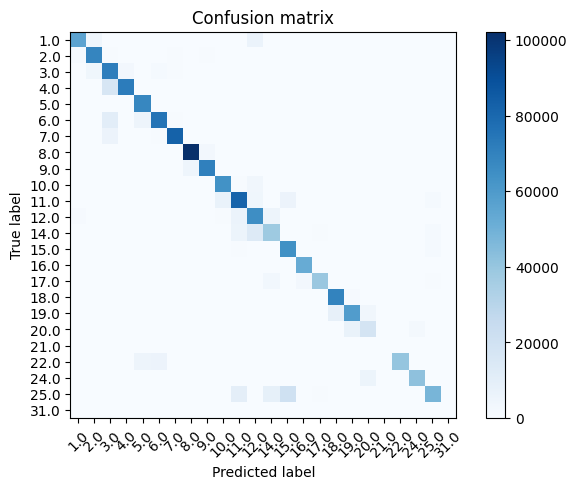

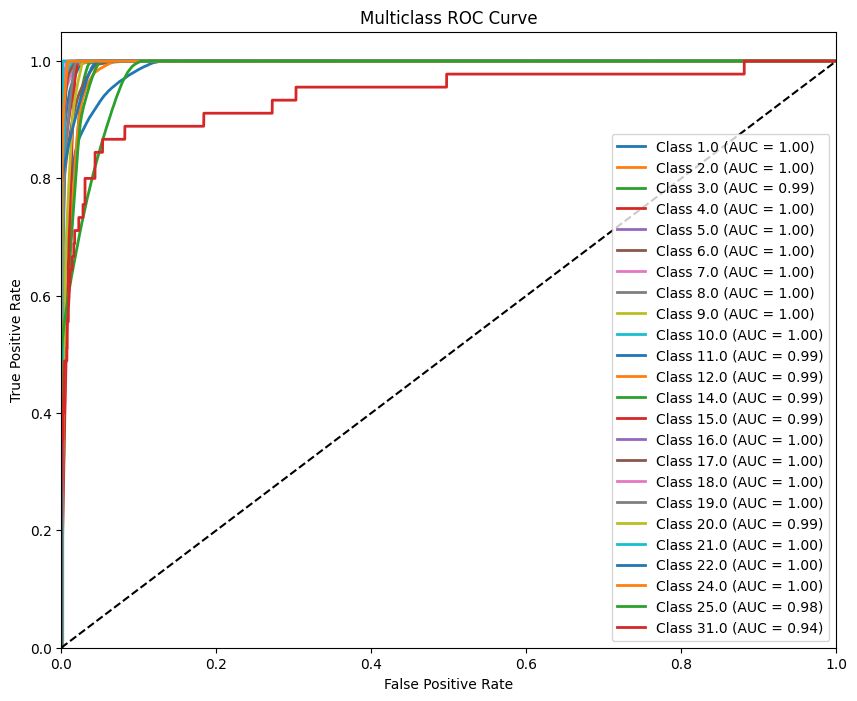

In [6]:
from sklearn import metrics

cardinalities = [len(label_encoders[col].classes_) for col in X_train.columns]
num_classes = len(y_le.classes_)

model = TabTransformer(
    cardinalities=cardinalities,
    embed_dim=64,
    depth=4,           # 4 transformer blocks
    heads=8,           # 8 attention heads 
    ff_dim=256,
    dropout=0.1,
    num_classes=num_classes
)

model.compile(
    optimizer=tf.keras.optimizers.AdamW(weight_decay=0.004, 
                                        beta_1=0.9, 
                                        beta_2=0.999, 
                                        epsilon=1e-07),
    loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True),
    metrics=["accuracy"]
)

monitor = tf.keras.callbacks.EarlyStopping(monitor='val_loss', min_delta=1e-5, patience=10, verbose=1, mode='min', restore_best_weights=True)
checkpointer = tf.keras.callbacks.ModelCheckpoint(filepath='model_5.weights.h5', save_best_only=True, save_weights_only=True)

model.fit(X_train_encoded, y_train_encoded, 
          epochs=50,
          batch_size=4096,
          callbacks=[monitor, checkpointer])

pred = model.predict(X_test_encoded)
pred_classes = pred.argmax(axis=1)

score = metrics.accuracy_score(y_test_encoded, pred_classes)

f1 = metrics.f1_score(y_test_encoded, pred_classes, average='weighted')
print(f'Average F1: {f1}')

print(metrics.classification_report(y_test_encoded, pred_classes))

cm = metrics.confusion_matrix(y_test_encoded, pred_classes)
print(cm)

labels = list(map(str, y_le.classes_))
plt.figure()
plot_confusion_matrix(cm, labels)
plt.show()

pred_probs = tf.nn.softmax(pred, axis=1).numpy()
plot_multiclass_roc(y_test_encoded, pred_probs, labels)